In [75]:
# Implementar un agrupamiento y buscar las tiendas modelos de cada grupo de tiendas a partir de su consumo electrico 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# lectura de documento
df_energia = pd.read_csv('../data/consumos_energia_2024-01-01_2023-10-29.csv')
df_energia.head()

,id_medidor,measure_date,consumo_kwh
0,200302,2024-01-21 21:00:00.000,219.1875
1,200241,2024-02-15 21:00:00.000,204.7500
2,200302,2024-01-22 04:00:00.000,102.0625
3,200302,2024-01-22 05:00:00.000,102.1875
4,200302,2024-01-22 06:00:00.000,110.1250


In [76]:
# revision de datos faltantes
df_energia.isna().sum()

id_medidor      0
measure_date    0
consumo_kwh     0
dtype: int64

In [77]:
# total de medidores
print(f"Total de medidores : {len(df_energia.id_medidor.unique())}")

Total de medidores : 121


In [78]:
# aplicar suavizado de curvas 
df = []
id_medidor = df_energia.id_medidor.unique()
for idm in id_medidor:
    query = df_energia.query("id_medidor == @idm").copy()
    query['consumo'] = query.consumo_kwh.rolling(window=10).mean()
    df.append(query[['id_medidor','measure_date','consumo']])
df = pd.concat(df)
df = df.dropna()
df

,id_medidor,measure_date,consumo
10,200302,2024-01-22 12:00:00.000,237.79375
11,200302,2024-01-22 13:00:00.000,256.03750
12,200302,2024-01-22 14:00:00.000,289.56875
13,200302,2024-01-22 15:00:00.000,324.25625
2464,200302,2024-06-19 11:00:00.000,343.11875
...,...,...,...
1830398,200109,2025-09-19 16:00:00.000,23.75000
1830399,200109,2025-09-19 17:00:00.000,23.97500
1830400,200109,2025-09-19 18:00:00.000,23.70000
1830401,200109,2025-09-19 19:00:00.000,23.67500


In [79]:
# por cada medidor tomare un promedio de su hora, dia_semana, estacion
# 1. transformar fecha a datetime y crear una nueva variable de 'hora'
df['measure_date'] = pd.to_datetime(df['measure_date'])
df['fecha_norm'] = df.measure_date.dt.normalize()
df['dia'] = df.measure_date.dt.day
df['hora'] = df.measure_date.dt.hour
df['mes'] = df.measure_date.dt.month
df['dia_ano'] = df.measure_date.dt.dayofyear
df['dia_semana'] = df.measure_date.dt.day_of_week + 1 
df['estacion'] = df.measure_date.dt.quarter

# obtener mediana por horas y luego obtener max y min de los promedio de las horas 
df_med_horas = df.groupby(['id_medidor','hora']).agg(
    med_kwh = ('consumo','median')
).reset_index()

# obtener el promedio consumo noche y dia, ademas de sus % 

# ahora si, obtener el promedio,std,max,min de consumo de cada medidor 
df_detalles = df_med_horas.groupby(['id_medidor']).agg(
    promedio_kwh = ('med_kwh','mean')
).reset_index()

df_detalles

,id_medidor,promedio_kwh
0,200069,243.163802
1,200070,79.511979
2,200071,155.620312
3,200072,93.597255
4,200073,150.174635
...,...,...
116,200545,8.622236
117,200546,121.209154
118,200547,86.059337
119,200548,38.377842


In [80]:
horas_apertura = [i for i in range(8,22)]

# obtener consumos apertura tienda y sumar su consumo
df_apertura = df[df.hora.isin(horas_apertura)].groupby(['id_medidor','fecha_norm']).agg(
     consumo_apertura = ('consumo','sum')   
).reset_index()

# obtener consumos cierres tienda y sumar consumo
df_cierre = df[~df.hora.isin(horas_apertura)].groupby(['id_medidor','fecha_norm']).agg(
     consumo_cierre = ('consumo','sum')   
).reset_index()

df_consumos_totales = df_apertura.merge(df_cierre, on=['id_medidor','fecha_norm'], how='left')

# obtener los porcentajes de consumos
df_consumos_totales['total_consumo'] = df_consumos_totales.consumo_apertura + df_consumos_totales.consumo_cierre
df_consumos_totales['por_apertura'] = df_consumos_totales.consumo_apertura / df_consumos_totales.total_consumo
df_consumos_totales['por_cierre'] = df_consumos_totales.consumo_cierre / df_consumos_totales.total_consumo

# agrupar por medidores 
df_por_agrupado = df_consumos_totales.groupby('id_medidor').agg(
    p_p_apertura = ('por_apertura','mean'),
    p_p_cierre = ('por_cierre','mean'),
    d_p_apertura = ('por_apertura','std'),
    d_p_cierre = ('por_cierre','std')
).reset_index()

# agrupar a detalles 
df_detalles = df_detalles.merge(df_por_agrupado, on='id_medidor',how='left')

In [81]:
df_detalles

,id_medidor,promedio_kwh,p_p_apertura,p_p_cierre,d_p_apertura,d_p_cierre
0,200069,243.163802,0.635230,0.364770,0.086708,0.086708
1,200070,79.511979,0.683268,0.316732,0.143818,0.143818
2,200071,155.620312,0.628944,0.371056,0.066674,0.066674
3,200072,93.597255,0.680852,0.319148,0.110367,0.110367
4,200073,150.174635,0.620331,0.379669,0.048007,0.048007
...,...,...,...,...,...,...
116,200545,8.622236,0.642396,0.357604,0.146048,0.146048
117,200546,121.209154,0.643892,0.356108,0.073902,0.073902
118,200547,86.059337,0.651314,0.348686,0.057471,0.057471
119,200548,38.377842,0.666428,0.333572,0.079855,0.079855


Calculando WCSS para el Método del Codo...


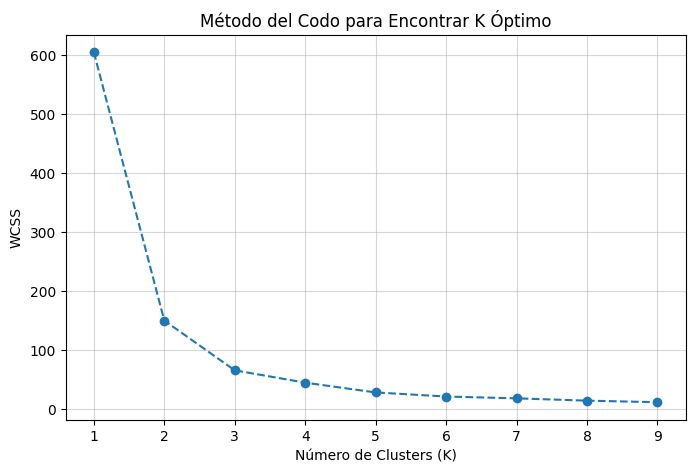


Aplicando K-Means con K = 3...
Aplicando t-SNE para visualización (Perplexity=30)...


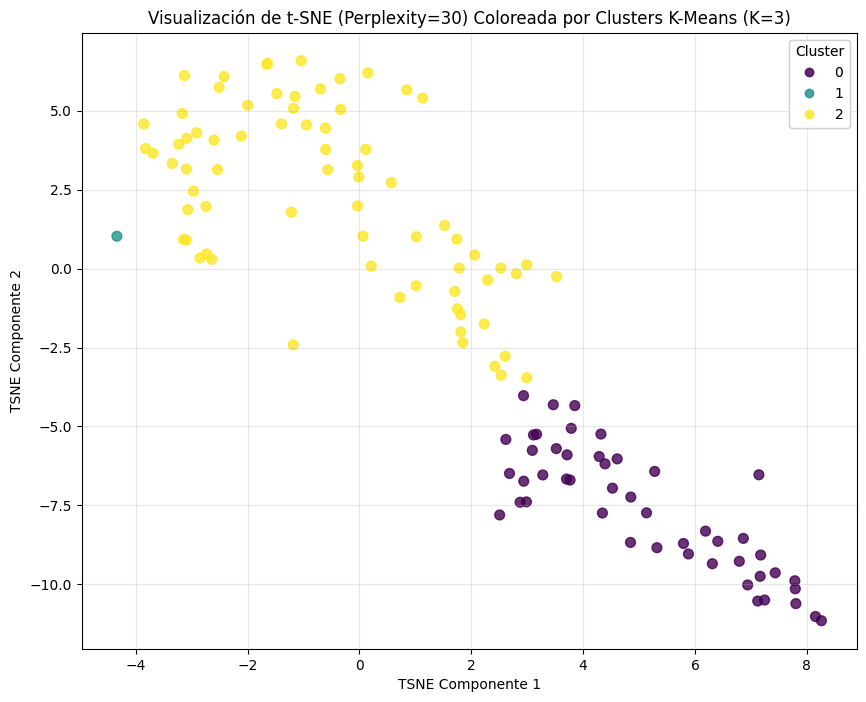

Primeras 5 filas con resultados:
   id_medidor  Cluster    TSNE_1    TSNE_2  promedio_kwh  p_p_apertura  \
0      200069        0  7.435050 -9.632721    243.163802      0.635230   
1      200070        2 -3.143876  0.917858     79.511979      0.683268   
2      200071        0  3.766389 -6.695742    155.620312      0.628944   
3      200072        2 -2.849961  0.332430     93.597255      0.680852   
4      200073        0  2.938691 -6.732380    150.174635      0.620331   

   p_p_cierre  d_p_apertura  d_p_cierre  
0    0.364770      0.086708    0.086708  
1    0.316732      0.143818    0.143818  
2    0.371056      0.066674    0.066674  
3    0.319148      0.110367    0.110367  
4    0.379669      0.048007    0.048007  


In [82]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


df_clusters = df_detalles.copy()

# Escalamiento de los datos
features = ['promedio_kwh', 'p_p_apertura', 'p_p_cierre', 'd_p_apertura', 'd_p_cierre']
X = df_clusters[features]

# Limpieza de datos
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X_values = X.values

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

# resultados finales
df_results = df_clusters.iloc[X.index].copy().reset_index(drop=True)


# estimacion del codo 
# ------------------------------------------------------------------
wcss = [] 
max_k = 10 

print("Calculando WCSS para el Método del Codo...")

for k in range(1, max_k):
    # n_init='auto' es el valor recomendado
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto') 
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# graficar codo
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True, alpha=0.5)
plt.show()



K_OPTIMO = 3

print(f"\nAplicando K-Means con K = {K_OPTIMO}...")

kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Añadir etiquetas de cluster al DataFrame de resultados
df_results['Cluster'] = cluster_labels


# Reduccion de dimensionalidad
PERPLEXITY_VAL = 30 

print(f"Aplicando t-SNE para visualización (Perplexity={PERPLEXITY_VAL})...")

tsne = TSNE(
    n_components=2, 
    perplexity=PERPLEXITY_VAL, 
    random_state=42, 
    learning_rate='auto',
    n_jobs=-1 # Uso de todos los núcleos para acelerar
)
X_tsne = tsne.fit_transform(X_scaled)

# Anadir las coordenadas
df_results['TSNE_1'] = X_tsne[:, 0]
df_results['TSNE_2'] = X_tsne[:, 1]


# Visualizacion del t-sne
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_results['TSNE_1'], 
    df_results['TSNE_2'], 
    c=df_results['Cluster'], # Colorear por la etiqueta de K-Means
    cmap='viridis', 
    s=50, 
    alpha=0.8
)
plt.title(f'Visualización de t-SNE (Perplexity={PERPLEXITY_VAL}) Coloreada por Clusters K-Means (K={K_OPTIMO})')
plt.xlabel('TSNE Componente 1')
plt.ylabel('TSNE Componente 2')


legend1 = plt.legend(*scatter.legend_elements(), 
                     loc="upper right", 
                     title="Cluster")
plt.gca().add_artist(legend1)
plt.grid(True, alpha=0.3)
plt.show()

print("Primeras 5 filas con resultados:")
print(df_results[['id_medidor', 'Cluster', 'TSNE_1', 'TSNE_2'] + features].head())

<h3>Aplicar modelo para consumo energia</h3>

In [119]:
# seleccionar medidor y grupos 
df_grupos = df_results[['id_medidor','Cluster']].copy()

# hacer merge con el dataset original de energia
energia = df.merge(df_grupos, on=['id_medidor'],how='left')
energia = energia[(energia.consumo > 1)&(energia.consumo < 300)]
energia.head()

,id_medidor,measure_date,consumo,fecha_norm,dia,hora,mes,dia_ano,dia_semana,estacion,Cluster
0,200302,2024-01-22 12:00:00,237.79375,2024-01-22,22,12,1,22,1,1,0
1,200302,2024-01-22 13:00:00,256.03750,2024-01-22,22,13,1,22,1,1,0
2,200302,2024-01-22 14:00:00,289.56875,2024-01-22,22,14,1,22,1,1,0
20,200302,2024-06-20 20:00:00,295.71250,2024-06-20,20,20,6,172,4,2,0
21,200302,2024-06-20 21:00:00,273.28750,2024-06-20,20,21,6,172,4,2,0


<Axes: xlabel='consumo'>

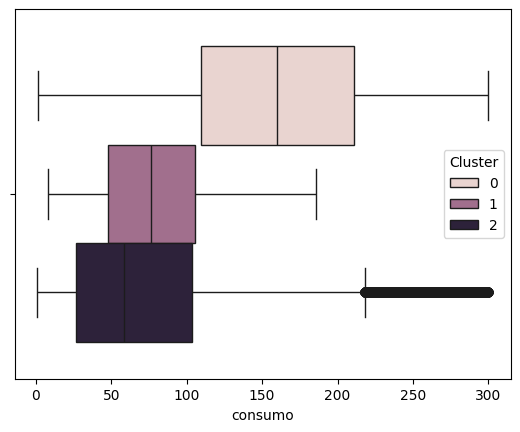

In [120]:
import seaborn as sns 

sns.boxplot(x=energia.consumo,hue=energia.Cluster)

In [121]:
# aplicar nueva columna de  horario atencion 
energia['apertura'] = '0'
energia.loc[energia.hora.isin(horas_apertura),'apertura'] = 1 
energia.head()

,id_medidor,measure_date,consumo,fecha_norm,dia,hora,mes,dia_ano,dia_semana,estacion,Cluster,apertura
0,200302,2024-01-22 12:00:00,237.79375,2024-01-22,22,12,1,22,1,1,0,1
1,200302,2024-01-22 13:00:00,256.03750,2024-01-22,22,13,1,22,1,1,0,1
2,200302,2024-01-22 14:00:00,289.56875,2024-01-22,22,14,1,22,1,1,0,1
20,200302,2024-06-20 20:00:00,295.71250,2024-06-20,20,20,6,172,4,2,0,1
21,200302,2024-06-20 21:00:00,273.28750,2024-06-20,20,21,6,172,4,2,0,1


In [128]:
# implementar modelos 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# features y target 
X = energia.drop(['id_medidor','measure_date','consumo','fecha_norm'],axis=1)
print(X)
y = energia.consumo 

# separar datos en etrenamiento y test 
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42, test_size=0.2)

# entrenamiento modelo 
rgl = LinearRegression().fit(X_train,y_train)
tree = DecisionTreeRegressor(max_depth=10,criterion='squared_error',max_features=5,splitter='best').fit(X_train,y_train)
rf = RandomForestRegressor().fit(X_train,y_train)

y_pred_r = rgl.predict(X_test)
y_pred_t = tree.predict(X_test)
y_pred_rf = rf.predict(X_test)

# metricas RMSE, MAPE 
rmse = mean_squared_error(y_pred_r,y_test) ** 0.5
mape = mean_absolute_percentage_error(y_pred_r,y_test)
rmse_t = mean_squared_error(y_pred_t,y_test) ** 0.5
mape_t = mean_absolute_percentage_error(y_pred_t,y_test)
rmse_rf = mean_squared_error(y_pred_rf,y_test) ** 0.5
mape_rf = mean_absolute_percentage_error(y_pred_rf, y_test)

print(f"LINEAR REGRESSION RMSE ({rmse}) , MAPE ({mape})")
print(f"DECISION TREE REGRESSOR RMSE ({rmse_t}) , MAPE ({mape_t})")
print(f"RANDOM FOREST RMSE ({rmse_rf}) , MAPE ({mape_rf})")

         dia  hora  mes  dia_ano  dia_semana  estacion  Cluster apertura
0         22    12    1       22           1         1        0        1
1         22    13    1       22           1         1        0        1
2         22    14    1       22           1         1        0        1
20        20    20    6      172           4         2        0        1
21        20    21    6      172           4         2        0        1
...      ...   ...  ...      ...         ...       ...      ...      ...
1843383   19    16    9      262           5         3        2        1
1843384   19    17    9      262           5         3        2        1
1843385   19    18    9      262           5         3        2        1
1843386   19    19    9      262           5         3        2        1
1843387   19    20    9      262           5         3        2        1

[1697642 rows x 8 columns]
LINEAR REGRESSION RMSE (57.793131988869746) , MAPE (0.5157562327622194)
DECISION TREE REGRESSOR 

<Axes: ylabel='consumo'>

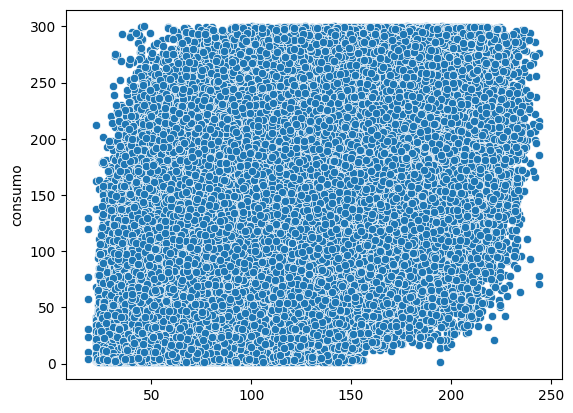